Agentless Statistics:
  Run 1: 95 bugs
  Run 2: 96 bugs
  Run 3: 96 bugs
  Union: 106 bugs
  Intersection: 86 bugs

BLAgent Statistics:
  Run 1: 107 bugs
  Run 2: 102 bugs
  Run 3: 115 bugs
  Union: 136 bugs
  Intersection: 73 bugs

Figures saved: repair_overlaps.pdf and repair_overlaps.png


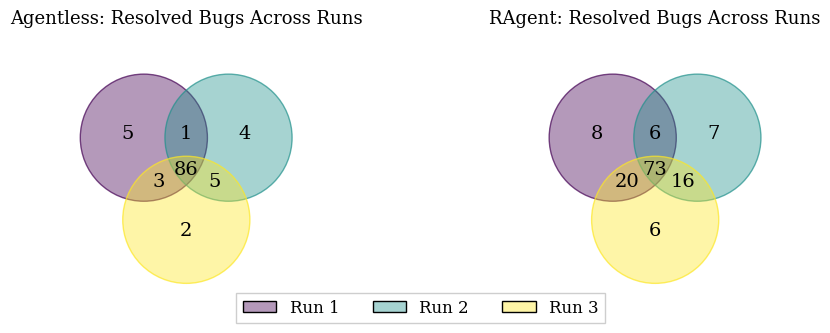

In [1]:
import json

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from venn import venn

# Set publication-quality parameters
plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts for editability

# --- Load data ---
agentless_data_file = "../results/rq2-1/repair_results/run_1/agentless/agentless_majority_voting_and_regression_and_reproduction_evaluation.json"
agentless_data_file_2 = "../results/rq2-1/repair_results/run_2/agentless/agentless_majority_voting_and_regression_and_reproduction_evaluation.json"
agentless_data_file_3 = "../results/rq2-1/repair_results/run_3/agentless/agentless_majority_voting_and_regression_and_reproduction_evaluation.json"

rag_data_file_3 = "../results/rq2-1/repair_results/run_1/blagent/blagent_majority_voting_and_regression_and_reproduction_evaluation.json"
rag_data_file_4 = "../results/rq2-1/repair_results/run_2/blagent/blagent_majority_voting_and_regression_and_reproduction_evaluation.json"
rag_data_file = "../results/rq2-1/repair_results/run_3/blagent/blagent_majority_voting_and_regression_and_reproduction_evaluation.json"

with open(agentless_data_file, "r") as f:
    agentless_data_1 = json.load(f)

with open(agentless_data_file_2, "r") as f:
    agentless_data_2 = json.load(f)

with open(agentless_data_file_3, "r") as f:
    agentless_data_3 = json.load(f)

with open(rag_data_file_3, "r") as f:
    ragfix_data_1 = json.load(f)
with open(rag_data_file_4, "r") as f:
    ragfix_data_2 = json.load(f)
with open(rag_data_file, "r") as f:
    ragfix_data_3 = json.load(f)

# --- Prepare sets ---
A = set(agentless_data_1["resolved_ids"])
B = set(agentless_data_2["resolved_ids"])
X = set(agentless_data_3["resolved_ids"])
C = set(ragfix_data_1["resolved_ids"])
D = set(ragfix_data_2["resolved_ids"])
Y = set(ragfix_data_3["resolved_ids"])

# --- Create figure with two subplots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- First Venn plot ---
venn_data_1 = {
    "Agentless (Run 1)": A,
    "Agentless (Run 2)": B,
    "Agentless (Run 3)": X,
}
venn_obj1 = venn(venn_data_1, ax=ax1, fontsize=14, legend_loc=None)
ax1.set_title("Agentless: Resolved Bugs Across Runs", fontsize=13)

# --- Second Venn plot ---
venn_data_2 = {"RAgent (Run 1)": C, "RAgent (Run 2)": D, "RAgent (Run 3)": Y}
venn_obj2 = venn(venn_data_2, ax=ax2, fontsize=14, legend_loc=None)
ax2.set_title("RAgent: Resolved Bugs Across Runs", fontsize=13)

# Extract actual colors from the venn diagram patches
colors = []
for patch in ax1.patches:
    if hasattr(patch, 'get_facecolor'):
        fc = patch.get_facecolor()
        if fc[3] > 0.1:  # Only visible patches
            colors.append(fc)
            if len(colors) == 3:
                break

# Create a single shared legend with actual venn colors
legend_elements = [
    Patch(facecolor=colors[0], edgecolor='black', label='Run 1'),
    Patch(facecolor=colors[1], edgecolor='black', label='Run 2'),
    Patch(facecolor=colors[2], edgecolor='black', label='Run 3')
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=3,
    fontsize=12,
    frameon=True,
    fancybox=False,
    shadow=False,
    # edgecolor='black',
    framealpha=0.95,
    bbox_to_anchor=(0.5, 0.15)
)

# Print statistics for paper
print(f"Agentless Statistics:")
print(f"  Run 1: {len(A)} bugs")
print(f"  Run 2: {len(B)} bugs")
print(f"  Run 3: {len(X)} bugs")
print(f"  Union: {len(A | B | X)} bugs")
print(f"  Intersection: {len(A & B & X)} bugs")
print(f"\nBLAgent Statistics:")
print(f"  Run 1: {len(C)} bugs")
print(f"  Run 2: {len(D)} bugs")
print(f"  Run 3: {len(Y)} bugs")
print(f"  Union: {len(C | D | Y)} bugs")
print(f"  Intersection: {len(C & D & Y)} bugs")

# Save plot with high quality
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Make room for the shared legend
plt.savefig("repair_overlaps.pdf", dpi=300, bbox_inches="tight", format='pdf')
plt.savefig("repair_overlaps.png", dpi=300, bbox_inches="tight", format='png')
print(f"\nFigures saved: repair_overlaps.pdf and repair_overlaps.png")
plt.show()

In [2]:
UA = A | B | X          # Agentless union across runs
UR = C | D | Y          # RAgent union across runs

print("\nAcross-approach (union across runs):")
print(f"  Agentless union (UA): {len(UA)} bugs")
print(f"  RAgent union (UR): {len(UR)} bugs")
print(f"  Either approach (UA ∪ UR): {len(UA | UR)} bugs")
print(f"  Both approaches (UA ∩ UR): {len(UA & UR)} bugs")
print(f"  Agentless-only (UA \\ UR): {len(UA - UR)} bugs")
print(f"  RAgent-only (UR \\ UA): {len(UR - UA)} bugs")


Across-approach (union across runs):
  Agentless union (UA): 106 bugs
  RAgent union (UR): 136 bugs
  Either approach (UA ∪ UR): 141 bugs
  Both approaches (UA ∩ UR): 101 bugs
  Agentless-only (UA \ UR): 5 bugs
  RAgent-only (UR \ UA): 35 bugs


In [3]:
from math import comb

UA = A | B | X
UR = C | D | Y
all_bugs = sorted(list(UA | UR))  # or the full SWE-bench ids if you have them

b = 0  # Agentless only
c = 0  # RAgent only
for bug in all_bugs:
    a = bug in UA
    r = bug in UR
    if a and (not r):
        b += 1
    elif r and (not a):
        c += 1

# Exact two-sided binomial p-value
n = b + c
if n == 0:
    p_value = 1.0
else:
    k = min(b, c)
    # two-sided: 2 * P(X <= k) where X ~ Bin(n, 0.5)
    p_value = 2.0 * sum(comb(n, i) * (0.5 ** n) for i in range(0, k + 1))
    p_value = min(p_value, 1.0)

print(f"McNemar b (Agentless-only)={b}, c (BLAgent-only)={c}, n={n}, p={p_value:.6g}")

McNemar b (Agentless-only)=5, c (BLAgent-only)=35, n=40, p=1.38261e-06


/tmp/ipykernel_827441/2475095275.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


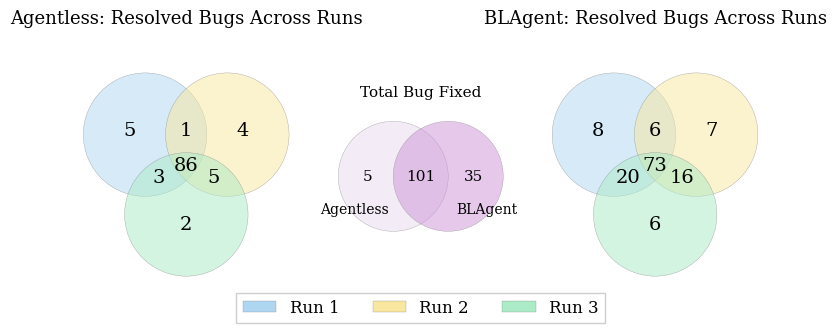

In [4]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

UA = A | B | X
UR = C | D | Y

# Paper-friendly colors for runs (soft, distinct, print-safe)
run_colors = ["#AED6F1", "#F9E79F", "#ABEBC6"]  # Light blue, light yellow, light green
run_cmap = ListedColormap(run_colors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Agentless runs
venn_obj1 = venn(
    {"Run 1": A, "Run 2": B, "Run 3": X},
    ax=ax1, fontsize=14, legend_loc=None,
    cmap=run_cmap, alpha=0.5
)
# Add light borders to all patches
for patch in ax1.patches:
    patch.set_edgecolor('gray')
    patch.set_linewidth(0.2)
ax1.set_title("Agentless: Resolved Bugs Across Runs", fontsize=13)

# RAgent runs (same cmap => same Run colors)
venn_obj2 = venn(
    {"Run 1": C, "Run 2": D, "Run 3": Y},
    ax=ax2, fontsize=14, legend_loc=None,
    cmap=run_cmap, alpha=0.5
)
# Add light borders to all patches
for patch in ax2.patches:
    patch.set_edgecolor('gray')
    patch.set_linewidth(0.2)
ax2.set_title("BLAgent: Resolved Bugs Across Runs", fontsize=13)

# Across-methods inset with distinct colors
ax_methods = fig.add_axes([0.365, 0.18, 0.27, 0.55])
ax_methods.set_title("Total Bug Fixed", fontsize=11, pad=2)

# Distinct paper-friendly colors for methods comparison
method_colors = ["#E8DAEF", "#CE93D8"]  # Light purple for Agentless, light mint for BLAGent
method_cmap = ListedColormap(method_colors)

venn_obj3 = venn(
    {"Agentless": UA, "BLAgent": UR},
    ax=ax_methods, fontsize=11, legend_loc=None,
    cmap=method_cmap, alpha=0.5
)
# Add light borders to all patches
for patch in ax_methods.patches:
    patch.set_edgecolor('gray')
    patch.set_linewidth(0.2)

# Adjust y-axis limits to reduce gap between title and diagram
ax_methods.set_ylim(-0.15, 0.85)

# Add method names directly on the circles (adjusted positions)
ax_methods.text(0.20, 0.35, "Agentless", fontsize=10, 
                ha='center', va='center')
ax_methods.text(0.80, 0.35, "BLAgent", fontsize=10, 
                ha='center', va='center')

ax_methods.set_xticks([]); ax_methods.set_yticks([])
for spine in ax_methods.spines.values():
    spine.set_visible(False)

# Shared run legend with exact same colors
legend_elements = [
    Patch(facecolor=run_colors[0], edgecolor="gray", linewidth=0.2, label="Run 1"),
    Patch(facecolor=run_colors[1], edgecolor="gray", linewidth=0.2, label="Run 2"),
    Patch(facecolor=run_colors[2], edgecolor="gray", linewidth=0.2, label="Run 3"),
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    fontsize=12,
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    bbox_to_anchor=(0.5, 0.15)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig("repair_overlaps.pdf", dpi=300, bbox_inches="tight")
plt.savefig("repair_overlaps.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
import json
from scipy.stats import binomtest

def mcnemar_exact_p(resA, resR, all_ids):
    A = set(resA)
    R = set(resR)
    U = set(all_ids)

    # paired outcomes
    b10 = sum((i in A) and (i not in R) for i in U)  # Agentless only
    b01 = sum((i not in A) and (i in R) for i in U)  # RAgent only

    n = b01 + b10
    if n == 0:
        return {"b01": b01, "b10": b10, "p": 1.0}  # identical outcomes on all bugs

    p = binomtest(k=min(b01, b10), n=n, p=0.5, alternative="two-sided").pvalue
    return {"b01": b01, "b10": b10, "p": p}

# --- Example wiring with your loaded sets A,B,X and C,D,Y ---
# You MUST provide the evaluated bug universe, e.g. from your JSON or dataset.
# Suppose each JSON has key "all_ids" or "instance_ids" (edit as needed):

all_ids = agentless_data_1["completed_ids"] + agentless_data_1["incomplete_ids"] + agentless_data_1["empty_patch_ids"]

len(all_ids)

p1 = mcnemar_exact_p(agentless_data_1["resolved_ids"], ragfix_data_2["resolved_ids"], all_ids)
p2 = mcnemar_exact_p(agentless_data_2["resolved_ids"], ragfix_data_1["resolved_ids"], all_ids)
p3 = mcnemar_exact_p(agentless_data_3["resolved_ids"], ragfix_data_3["resolved_ids"], all_ids)
print(p1, p2, p3)

{'b01': 21, 'b10': 14, 'p': np.float64(0.31050465907901537)} {'b01': 30, 'b10': 19, 'p': np.float64(0.15240777196147803)} {'b01': 34, 'b10': 15, 'p': np.float64(0.009399241523873059)}


In [8]:
import numpy as np
from scipy.stats import wilcoxon

def per_bug_counts_test(agent_runs, ragent_runs, all_ids):
    # agent_runs / ragent_runs: list of sets, length = 3 (or any R)
    U = list(all_ids)

    sA = np.array([sum(i in S for S in agent_runs) for i in U])
    sR = np.array([sum(i in S for S in ragent_runs) for i in U])

    print(sA, sR)

    d = sR - sA
    # Wilcoxon requires non-all-zero differences
    # if np.all(d == 0):
    #     return {"p": 1.0, "mean_diff": 0.0}

    stat, p = wilcoxon(d, zero_method="wilcox", alternative="two-sided")
    return {"p": p, "mean_diff": float(d.mean()), "median_diff": float(np.median(d))}

# Usage:
agent_runs = [A, B, X]
ragent_runs = [C, D, Y]
out = per_bug_counts_test(agent_runs, ragent_runs, all_ids)
print(out)

print(f"Wilcoxon signed-rank test p-value: {out['p']:.6g}")

[0 0 0 0 0 3 0 3 3 3 3 0 0 0 3 0 0 2 3 0 0 0 1 0 3 1 3 0 1 3 2 3 0 0 3 3 0
 2 0 3 0 3 0 3 0 0 3 3 0 3 3 0 0 3 3 1 0 3 3 0 0 0 0 0 3 0 3 0 3 0 0 0 0 3
 0 0 3 0 0 3 0 0 0 3 3 1 0 3 0 1 3 2 0 3 3 0 0 3 3 0 0 3 0 3 0 0 0 0 0 0 0
 3 0 3 0 0 3 0 0 0 0 3 0 0 3 3 0 0 0 0 2 0 2 3 3 2 0 1 0 3 3 0 0 3 3 0 0 3
 0 0 0 0 3 3 1 0 0 0 3 0 0 0 3 3 3 3 0 3 3 2 3 0 3 1 0 3 0 0 3 0 0 0 0 2 0
 0 0 0 0 0 3 3 0 0 0 0 0 0 0 0 0 0 0 3 3 3 0 0 0 0 0 3 3 0 0 0 0 0 3 0 0 0
 0 0 0 0 0 1 0 0 3 0 3 0 0 0 0 3 3 0 3 0 0 3 0 0 0 0 0 3 0 3 0 3 0 3 1 0 3
 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0] [1 0 0 2 3 3 0 3 3 3 3 0 0 0 3 0 0 3 3 0 0 0 0 0 2 1 1 0 3 2 2 3 0 0 3 3 1
 1 0 3 0 3 0 3 0 0 2 3 0 3 3 0 3 3 2 3 0 3 3 2 0 0 0 0 2 0 3 2 3 0 0 0 0 3
 0 0 3 0 0 2 0 0 0 3 3 3 0 3 2 0 3 2 0 3 3 0 0 3 3 0 0 3 0 2 1 0 0 0 0 0 0
 3 0 2 0 0 2 0 1 0 0 1 0 0 3 1 0 0 0 0 1 0 2 2 3 2 0 0 0 3 1 0 0 2 3 0 0 3
 0 0 0 0 3 2 2 0 0 0 3 0 0 0 2 3 3 3 0 3 0 2 3 0 3 2 0 2 0 0 2 0 2 0 0 3 0
 0 0 0 0 0 3 3 0 